Notebook serves as an insight into created dataset.

In [1]:
import random
import cv2
from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.utils.visualizer import Visualizer
from detectron2.data.datasets import register_coco_instances
import matplotlib.pyplot as plt
from pathlib import Path

In [101]:
datasets_to_remove = ["D3_M1_train", "D3_M1_val", "D3_M1_test", "D3_M2_train", "D3_M2_val", "D3_M2_test"]

for dataset_name in datasets_to_remove:
    if dataset_name in DatasetCatalog:
        del DatasetCatalog[dataset_name]

    if dataset_name in MetadataCatalog:
        del MetadataCatalog[dataset_name]

print("ok")

ok


In [102]:

def register_dataset(name, annotations_path, images_path):
    if name not in DatasetCatalog:
        register_coco_instances(name, {}, annotations_path, images_path)
    else:
        print(f"Dataset {name} is already registered is detectron library.")



COCO_DATASET_DIR = Path("C:\\Users\\WA\\Desktop\\badanie\\syncity3D\\COCO_DATASETS\\D3")
IMAGES_DIR = COCO_DATASET_DIR / "images"
ANNOTATIONS_DIR = COCO_DATASET_DIR / "annotations"


train_images_dir = IMAGES_DIR / "train"
val_images_dir = IMAGES_DIR / "val"
test_images_dir = IMAGES_DIR / "test"

# M1
train_ann_m1_dir = ANNOTATIONS_DIR / "instances_train_m1.json"
val_ann_m1_dir = ANNOTATIONS_DIR / "instances_val_m1.json"
test_ann_m1_dir = ANNOTATIONS_DIR / "instances_test_m1.json"

# M2
train_ann_m2_dir = ANNOTATIONS_DIR / "instances_train_m2.json"
val_ann_m2_dir = ANNOTATIONS_DIR / "instances_val_m2.json"
test_ann_m2_dir = ANNOTATIONS_DIR / "instances_test_m2.json"


register_dataset("D3_M1_train", train_ann_m1_dir, train_images_dir)
register_dataset("D3_M1_val", val_ann_m1_dir, train_images_dir)
register_dataset("D3_M1_test", test_ann_m1_dir, train_images_dir)

register_dataset("D3_M2_train", train_ann_m2_dir, train_images_dir)
register_dataset("D3_M2_val", val_ann_m2_dir, train_images_dir)
register_dataset("D3_M2_test", test_ann_m2_dir, train_images_dir)

print("= "*15)
print("Available Datasets:")
available_datasets = list(DatasetCatalog)

i = 0
print_factor = 5
while True:
    chunk = available_datasets[print_factor*(i): print_factor*(i+1)]
    if not chunk:
        break
    print(chunk)
    i += 1

= = = = = = = = = = = = = = = 
Available Datasets:
['coco_2014_train', 'coco_2014_val', 'coco_2014_minival', 'coco_2014_valminusminival', 'coco_2017_train']
['coco_2017_val', 'coco_2017_test', 'coco_2017_test-dev', 'coco_2017_val_100', 'keypoints_coco_2014_train']
['keypoints_coco_2014_val', 'keypoints_coco_2014_minival', 'keypoints_coco_2014_valminusminival', 'keypoints_coco_2017_train', 'keypoints_coco_2017_val']
['keypoints_coco_2017_val_100', 'coco_2017_train_panoptic_separated', 'coco_2017_train_panoptic_stuffonly', 'coco_2017_train_panoptic', 'coco_2017_val_panoptic_separated']
['coco_2017_val_panoptic_stuffonly', 'coco_2017_val_panoptic', 'coco_2017_val_100_panoptic_separated', 'coco_2017_val_100_panoptic_stuffonly', 'coco_2017_val_100_panoptic']
['lvis_v1_train', 'lvis_v1_val', 'lvis_v1_test_dev', 'lvis_v1_test_challenge', 'lvis_v0.5_train']
['lvis_v0.5_val', 'lvis_v0.5_val_rand_100', 'lvis_v0.5_test', 'lvis_v0.5_train_cocofied', 'lvis_v0.5_val_cocofied']
['cityscapes_fine_inst

In [103]:

m1_dataset_name = "D3_M1_train"
m2_dataset_name = "D3_M2_train"

# registry dicts build by detectron
m1_metadata = MetadataCatalog.get(m1_dataset_name)
m1_metadata_dict = m1_metadata.as_dict()

m2_metadata = MetadataCatalog.get(m2_dataset_name)
m2_metadata_dict = m2_metadata.as_dict()

m1_dataset_anns = DatasetCatalog.get(m1_dataset_name)
m2_dataset_anns = DatasetCatalog.get(m2_dataset_name)


print("M1 Metadata:")
print(m1_metadata)
#print(type(m1_metadata))
#print(type(m1_metadata_dict))

for key in m1_metadata_dict.keys():
   print(key, ": ", m1_metadata_dict[key]) 


# NOTE: in M2 we have created a class representing a facade with an category_id=1000, 
# which we could simply set to n_of_windows +1, but for the purpose of clearer distinction between we set it to a much higher number 
# detectron applies mapping for us

print("M2 Metadata:")
print(m2_metadata)
for key in m2_metadata_dict.keys():
   print(key, ": ", m2_metadata_dict[key]) 



Category ids in annotations are not in [1, #categories]! We'll apply a mapping for you.



M1 Metadata:
Metadata(name='D3_M1_train', json_file=WindowsPath('C:/Users/WA/Desktop/badanie/syncity3D/COCO_DATASETS/D3/annotations/instances_train_m1.json'), image_root=WindowsPath('C:/Users/WA/Desktop/badanie/syncity3D/COCO_DATASETS/D3/images/train'), evaluator_type='coco', thing_classes=['81', '84', '124', '147', '153', '184', '196', '198', '206', '225'], thing_dataset_id_to_contiguous_id={1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9})
name :  D3_M1_train
json_file :  C:\Users\WA\Desktop\badanie\syncity3D\COCO_DATASETS\D3\annotations\instances_train_m1.json
image_root :  C:\Users\WA\Desktop\badanie\syncity3D\COCO_DATASETS\D3\images\train
evaluator_type :  coco
M2 Metadata:
Metadata(name='D3_M2_train', json_file=WindowsPath('C:/Users/WA/Desktop/badanie/syncity3D/COCO_DATASETS/D3/annotations/instances_train_m2.json'), image_root=WindowsPath('C:/Users/WA/Desktop/badanie/syncity3D/COCO_DATASETS/D3/images/train'), evaluator_type='coco', thing_classes=['1_81', '1_84', '1_12

In [104]:
print("M1 Anns")
print(len(m1_dataset_anns))
for ann in m1_dataset_anns[:3]:
    print(ann)
    print()

print()
print("M2 Anns")
print(len(m2_dataset_anns))
for ann in m2_dataset_anns[:3]:
    print(ann)
    print()

M1 Anns
836
{'file_name': 'C:\\Users\\WA\\Desktop\\badanie\\syncity3D\\COCO_DATASETS\\D3\\images\\train\\m-Normal_SynCity3D_163.png', 'height': 3040, 'width': 6080, 'image_id': 1, 'annotations': [{'iscrowd': 0, 'bbox': [4451.0, 995.0, 596.0, 827.0], 'category_id': 2, 'segmentation': {'size': [3040, 6080], 'counts': 'Tlnl<ii0VU22O000001O0000000O2O00001O000O1000001O0O100000001O00001O00000O10001O00001N100000000O2O001O00000O10001O00001O0000000O101O00001O0O100000001O0O101O00000O10001O00001N10001O000O10001O00001N100000001O0000001O0O101O00000O2O000000001N10001O00001N100000001N1000001O000O2O00001O0O1000001O000O2O0000001N10001O00000O101O00001N10001O00001N10001O000O10001O00001N1000001O0O101O00001O0O101O00001N100000001N10001O00001N10001O000O2O00001O0O101O00001N10001N10001O0O10001O000O101O00001O0O101O00001N10001O000O2O001O00001N10001O000O2O00001O0O101O000O2O0O101O00001N10001O00001N101O00001N10001O000O2O00001O0O2O00001O0O1O2O00001O0O101O00001N10001O001N10001O000O2O001O000O2O0O101O000O2O001O000O2O00

In [105]:
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import ColorMode

m1_classes = len(m1_metadata.thing_classes)
m2_classes = len(m2_metadata.thing_classes)

#colors = [cm.get_cmap("Reds")(i)[:3] for i in range(m1_classes)]
#m1_colors = [cm.get_cmap("Reds")(i / (m1_classes - 1))[:3] for i in range(m1_classes)]
m1_colors = [ [int(x * 255) for x in plt.get_cmap("Reds")(i / (m1_classes - 1))[:3]]      for i in range(m1_classes) ]
m2_colors = [ [int(x * 255) for x in plt.get_cmap("Reds")(i / (m2_classes - 1))[:3]]      for i in range(m2_classes) ]
m2_colors[-1] = [0, 0, 255] #blue facade

print("COLORS:")
print(m1_colors)
print(m2_colors)

m1_metadata.set(thing_colors=m1_colors)
m2_metadata.set(thing_colors=m2_colors)


COLORS:
[[255, 245, 240], [254, 226, 213], [252, 195, 172], [252, 159, 129], [251, 124, 92], [245, 84, 60], [227, 47, 39], [193, 21, 27], [157, 13, 20], [103, 0, 12]]
[[255, 245, 240], [254, 228, 216], [252, 201, 180], [252, 171, 142], [251, 138, 106], [250, 105, 73], [241, 68, 50], [216, 37, 34], [187, 20, 25], [151, 11, 19], [0, 0, 255]]


namespace(name='D3_M2_train',
          json_file=WindowsPath('C:/Users/WA/Desktop/badanie/syncity3D/COCO_DATASETS/D3/annotations/instances_train_m2.json'),
          image_root=WindowsPath('C:/Users/WA/Desktop/badanie/syncity3D/COCO_DATASETS/D3/images/train'),
          evaluator_type='coco',
          thing_classes=['1_81',
                         '1_84',
                         '1_124',
                         '1_147',
                         '1_153',
                         '1_184',
                         '1_196',
                         '1_198',
                         '1_206',
                         '1_225',
                         '0_1000'],
          thing_dataset_id_to_contiguous_id={1: 0,
                                             2: 1,
                                             3: 2,
                                             4: 3,
                                             5: 4,
                                             6: 5,
                         

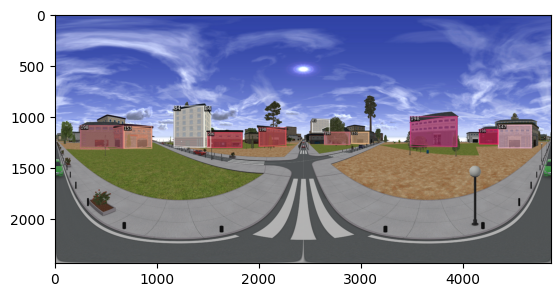

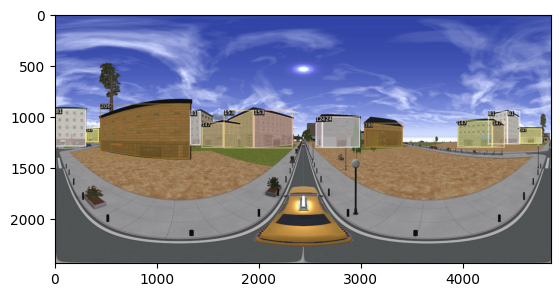

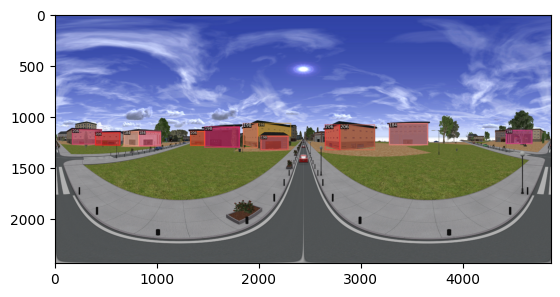

In [67]:
# with jittering
n_of_photos = 3
for d in random.sample(m1_dataset_anns, min(n_of_photos, len(m1_dataset_anns))):

    img = cv2.imread(d["file_name"])
    visualizer = Visualizer(img[:, :, ::-1], metadata=m1_metadata, scale=0.8, instance_mode=ColorMode.SEGMENTATION) # cv2 -> -1 
    out = visualizer.draw_dataset_dict(d)
    plt.imshow(out.get_image()[:, :, :])
    plt.show()

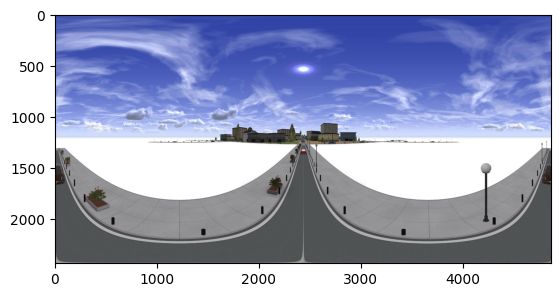

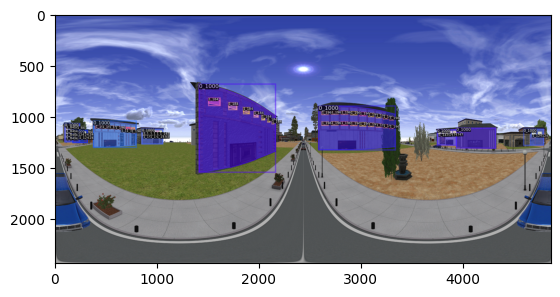

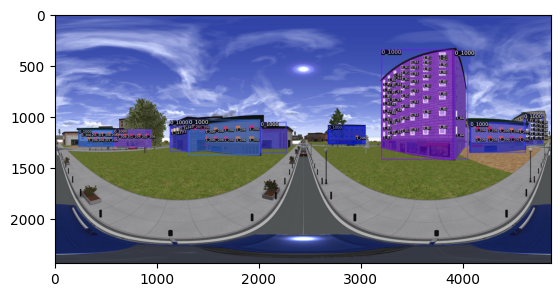

In [106]:
n_of_photos = 3
for d in random.sample(m2_dataset_anns, min(n_of_photos, len(m2_dataset_anns))):

    img = cv2.imread(d["file_name"])
    visualizer = Visualizer(img[:, :, ::-1], metadata=m2_metadata, scale=0.8, instance_mode=ColorMode.SEGMENTATION) # cv2 -> -1
    out = visualizer.draw_dataset_dict(d)
    plt.imshow(out.get_image()[:, :, :])
    plt.show()

In [119]:
from detectron2.utils.visualizer import _create_text_labels
from detectron2.structures import BitMasks, Boxes, BoxMode, Keypoints, PolygonMasks, RotatedBoxes
from PIL import Image
import time

SAVE_PATH = Path("C:\\Users\\WA\\Desktop\\misc\\dataset_verification")

def visualize_dataset(dataset_anns, n_of_photos, m_metadata, prefix="m", save_image=False):

    for i, d in enumerate(random.sample(dataset_anns, min(n_of_photos, len(dataset_anns)))):

        img = cv2.imread(d["file_name"])
        visualizer = Visualizer(img[:, :, ::-1], metadata=m_metadata, scale=0.8, instance_mode=ColorMode.SEGMENTATION) # cv2 -> -1
        
        annos = d.get("annotations", None)
        if annos:
            if "segmentation" in annos[0]:
                masks = [x["segmentation"] for x in annos]
            else:
                masks = None

            boxes = [ BoxMode.convert(x["bbox"], x["bbox_mode"], BoxMode.XYXY_ABS)
                        if len(x["bbox"]) == 4
                        else x["bbox"]
                        for x in annos
                    ]

            category_ids = [x["category_id"] for x in annos]
            #category_ids.sort()
            colors = [
                    [x / 255 for x in m_metadata.thing_colors[c]]
                    for c in category_ids
                ]
            
            #print("CATEGORIES:", category_ids)
            #print("COLORS:", colors)
            
            names = m_metadata.get("thing_classes", None)

            labels = _create_text_labels(
                        category_ids,
                        scores=None,
                        class_names=names,
                        is_crowd=[x.get("iscrowd", 0) for x in annos],
                    )
            
            out = visualizer.overlay_instances(labels=labels, boxes=boxes, masks=masks, keypoints=None, assigned_colors=colors)
            if save_image:
                image = Image.fromarray(out.get_image()[:, :, :])
                image.save(SAVE_PATH / f"{prefix}_{i}.png")

            #out = visualizer.draw_dataset_dict(d)
            plt.imshow(out.get_image()[:, :, :])
            plt.show()



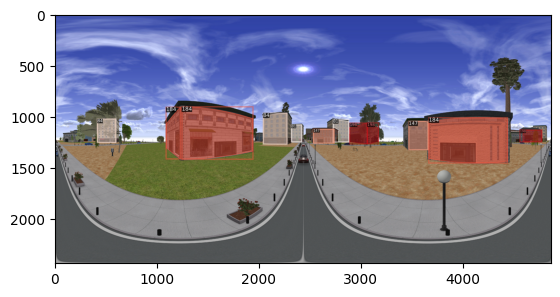

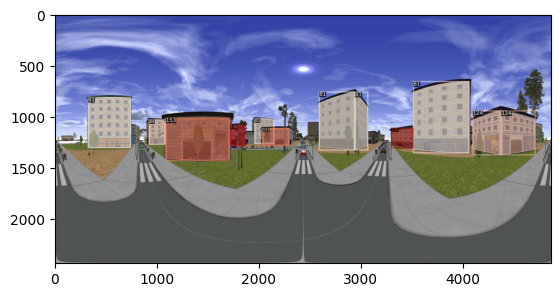

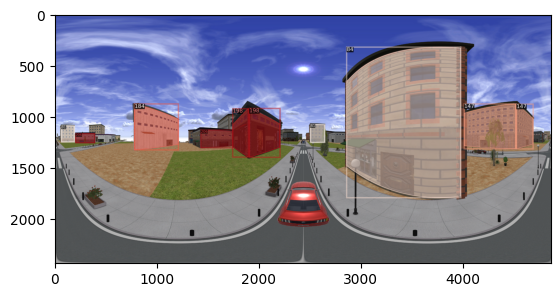

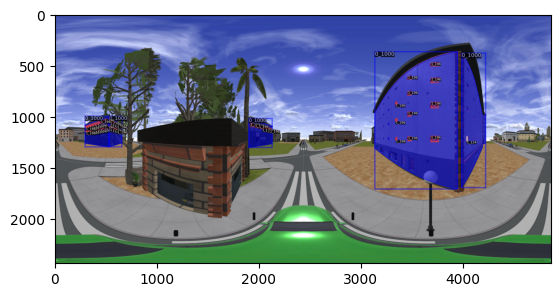

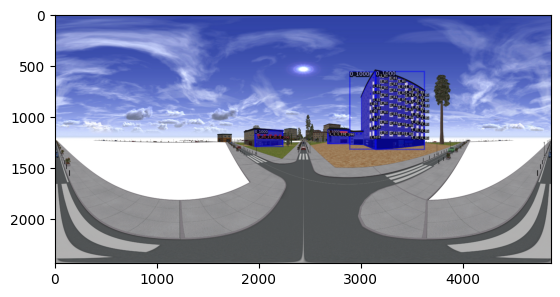

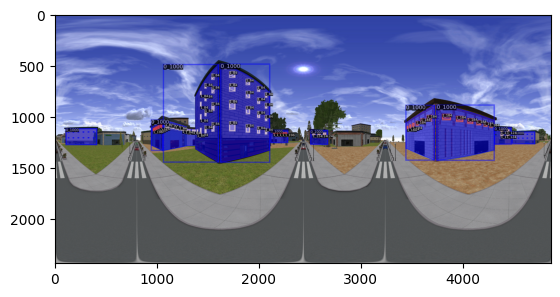

In [120]:
# to exclude jitter

n_of_photos = 3
visualize_dataset(m1_dataset_anns, n_of_photos, m1_metadata, prefix="m1", save_image=True)
visualize_dataset(m2_dataset_anns, n_of_photos, m2_metadata, prefix="m2", save_image=True)

In [ ]:
import pandas as pd

m1_images_data = []
m1_annotations_data = []
m2_images_data = []
m2_annotations_data = []


for img in m1_dataset_anns:

    m1_images_data.append({
        "image_id": img["image_id"],
        "file_name": img["file_name"],
        "width": img["width"],
        "height": img["height"],
        "num_annotations": len(img.get("annotations", []))
    })

    for anno in img.get("annotations", []):
        bbox = anno["bbox"] 
   
        bbox_width = bbox[2]
        bbox_height = bbox[3]
        area = bbox_width * bbox_height
        
        m1_annotations_data.append({
            "image_id": img["image_id"],
            "category_id": anno["category_id"],
            "bbox_width": bbox_width,
            "bbox_height": bbox_height,
            "bbox_area": area,

        })

for img in m2_dataset_anns:

    m2_images_data.append({
        "image_id": img["image_id"],
        "file_name": img["file_name"],
        "width": img["width"],
        "height": img["height"],
        "num_annotations": len(img.get("annotations", []))
    })

    for anno in img.get("annotations", []):
        bbox = anno["bbox"] 
   
        bbox_width = bbox[2]
        bbox_height = bbox[3]
        area = bbox_width * bbox_height
        
        m2_annotations_data.append({
            "image_id": img["image_id"],
            "category_id": anno["category_id"],
            "bbox_width": bbox_width,
            "bbox_height": bbox_height,
            "bbox_area": area,

        })


m1_df_images = pd.DataFrame(m1_images_data)
m1_df_annos = pd.DataFrame(m1_annotations_data)

m2_df_images = pd.DataFrame(m2_images_data)
m2_df_annos = pd.DataFrame(m2_annotations_data)

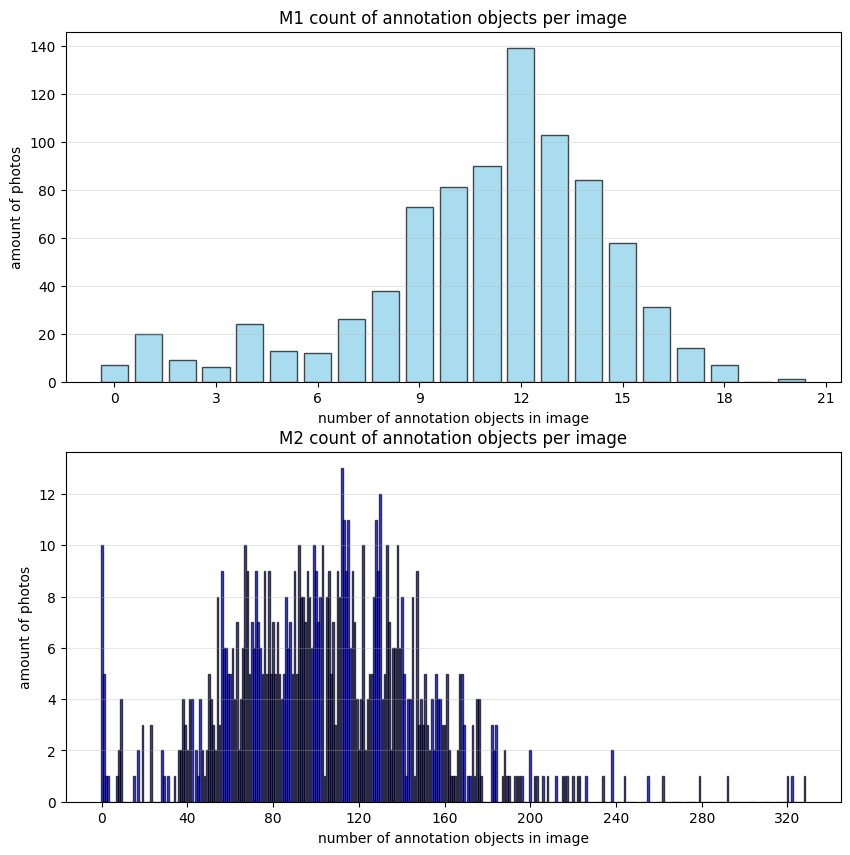

In [134]:
plt.figure(figsize=(10, 10))

plt.subplot(2, 1, 1)
plt.hist(
    m1_df_images["num_annotations"],
    bins=range(m1_df_images["num_annotations"].min(), m1_df_images["num_annotations"].max() + 2),
    color="skyblue",
    edgecolor="black",
    alpha=0.7,
    align="left",
    rwidth=0.8
)
plt.title("M1 count of annotation objects per image")
plt.xlabel("number of annotation objects in image")
plt.ylabel("amount of photos")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.grid(axis='y', alpha=0.3)


plt.subplot(2, 1, 2)
plt.hist(
    m2_df_images["num_annotations"],
    bins=range(m2_df_images["num_annotations"].min(), m2_df_images["num_annotations"].max() + 2),
    color="blue",
    edgecolor="black",
    alpha=0.7,
    align="left",
    rwidth=0.8
)
plt.title("M2 count of annotation objects per image")
plt.xlabel("number of annotation objects in image")
plt.ylabel("amount of photos")
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.grid(axis='y', alpha=0.3)

plt.show()

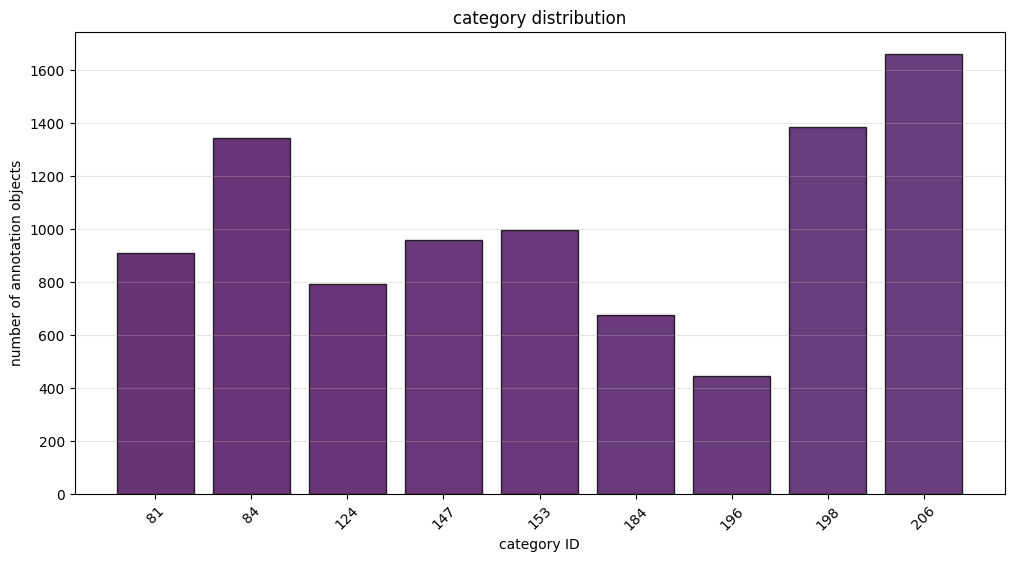

In [132]:
plt.figure(figsize=(12, 6))

class_counts = df_annos["category_id"].value_counts().sort_index()


plt.bar(
    x=class_counts.index, 
    height=class_counts.values, 
    color=plt.colormaps["viridis"](range(len(class_counts))), 
    edgecolor="black",
    alpha=0.8
)
plt.title("category distribution")
plt.xlabel("category ID")
plt.ylabel("number of annotation objects")


if m1_metadata.get("thing_classes"):
    plt.xticks(
        ticks=class_counts.index, 
        labels=[m1_metadata.thing_classes[i] for i in class_counts.index], 
        rotation=45
    )
else:
    plt.xticks(ticks=class_counts.index)

plt.grid(axis='y', alpha=0.3)
plt.show()